## ✨ Importing Dependencies

In [1]:
!pip install -q torch torchvision matplotlib pillow

In [2]:
!pip install -q timm torchsummary

In [ ]:
!pip install -q tensoData to Image Conversionrboard

## 📚 Library Imports

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from tqdm import tqdm
import random
import os

from PIL import Image, ImageDraw
import cv2

# Visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt  # Plotting library
import matplotlib.image as mpimg
import matplotlib.patches as patches

# model creation part 
import timm
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torch.utils.tensorboard import SummaryWriter


# metrics and model selection
from sklearn.model_selection import train_test_split  
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import classification_report, roc_curve, confusion_matrix
from sklearn.metrics import recall_score, precision_score

import warnings
warnings.simplefilter('ignore')

In [4]:
path = r"/kaggle/input/simple-vs-comminuted-fractures-x-ray-data/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Orginal"
print(os.listdir(path))

['Comminuted Bone Fracture', 'Simple Bone Fracture']


## 🖼️ Data to Image Conversion and visualization

In [5]:
def make_dataset_df(folders: list, save_csv: bool = False, ds_name:str="dataset") -> pd.DataFrame:
    data = []
    
    for folder in folders:
        if not os.path.exists(folder):
            print(f"Uyarı: {folder} klasörü bulunamadı!")
            continue
        else:
            # label = os.path.basename(folder).strip()  # folder.split('/')[-1]
            label = os.path.basename(os.path.normpath(folder)).strip()
            if not label:
                label = os.path.basename(os.path.dirname(folder))

        try:
            # for file_name in os.listdir(folder):
            for file_name in os.scandir(folder):
                file_path = os.path.join(folder, file_name)
                
                if os.path.isfile(file_path):
                    data.append((file_path, label))
        except OSError as e:
            print(f"Dosya listeleme hatası ({folder}): {e}")
            continue
    
    df = pd.DataFrame(data, columns=["file_path", "label"])

    if not data:
        print("Uyarı: Hiç veri bulunamadı!")
        return pd.DataFrame(columns=["file_path", "label"])
    
    if save_csv:
        try:
            print(f"CSV dosyası kaydedildi: {ds_name}.csv")
            df.to_csv(f"{ds_name}.csv", index=False)
        except Exception as e:
            print(f"CSV kaydetme hatası: {e}")
            
    return df

In [6]:
folders = [
    "/kaggle/input/simple-vs-comminuted-fractures-x-ray-data/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Augmented/Comminuted Bone Fracture",
    "/kaggle/input/simple-vs-comminuted-fractures-x-ray-data/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Augmented/Simple Bone Fracture",
]

df = make_dataset_df(folders,save_csv=False)
print("Shape of stroke dataset is:" ,df.shape)

Shape of stroke dataset is: (13677, 2)


In [7]:
df.head()

,file_path,label
0,/kaggle/input/simple-vs-comminuted-fractures-x...,Comminuted Bone Fracture
1,/kaggle/input/simple-vs-comminuted-fractures-x...,Comminuted Bone Fracture
2,/kaggle/input/simple-vs-comminuted-fractures-x...,Comminuted Bone Fracture
3,/kaggle/input/simple-vs-comminuted-fractures-x...,Comminuted Bone Fracture
4,/kaggle/input/simple-vs-comminuted-fractures-x...,Comminuted Bone Fracture


In [8]:
df.tail()

,file_path,label
13672,/kaggle/input/simple-vs-comminuted-fractures-x...,Simple Bone Fracture
13673,/kaggle/input/simple-vs-comminuted-fractures-x...,Simple Bone Fracture
13674,/kaggle/input/simple-vs-comminuted-fractures-x...,Simple Bone Fracture
13675,/kaggle/input/simple-vs-comminuted-fractures-x...,Simple Bone Fracture
13676,/kaggle/input/simple-vs-comminuted-fractures-x...,Simple Bone Fracture


In [9]:
df['label'].value_counts()

label
Comminuted Bone Fracture    7366
Simple Bone Fracture        6311
Name: count, dtype: int64

In [10]:
def plot_class_samples(df, samples_per_class=3):
    classes = df['label'].unique()
    fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 4, len(classes) * 4))
    if len(classes) == 1:
        axes = [axes]

    for i, label in enumerate(classes):
        class_data = df[df['label'] == label]
        images = class_data['file_path'].tolist()
        num_samples = min(samples_per_class, len(images))
        sample_images = random.sample(images, num_samples) if num_samples > 0 else []

        for j in range(samples_per_class):
            ax = axes[i][j] if len(classes) > 1 else axes[j]
            ax.axis('off')

            if j < num_samples:
                img = mpimg.imread(sample_images[j])
                ax.imshow(img, cmap='gray')
                color = random.choice(['red', 'green', 'blue', 'orange', 'purple'])
                rect = patches.Rectangle((0,0),1,1, transform=ax.transAxes,
                                         linewidth=4, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.set_title(f"{label}", fontsize=10)

    plt.tight_layout()
    plt.show()

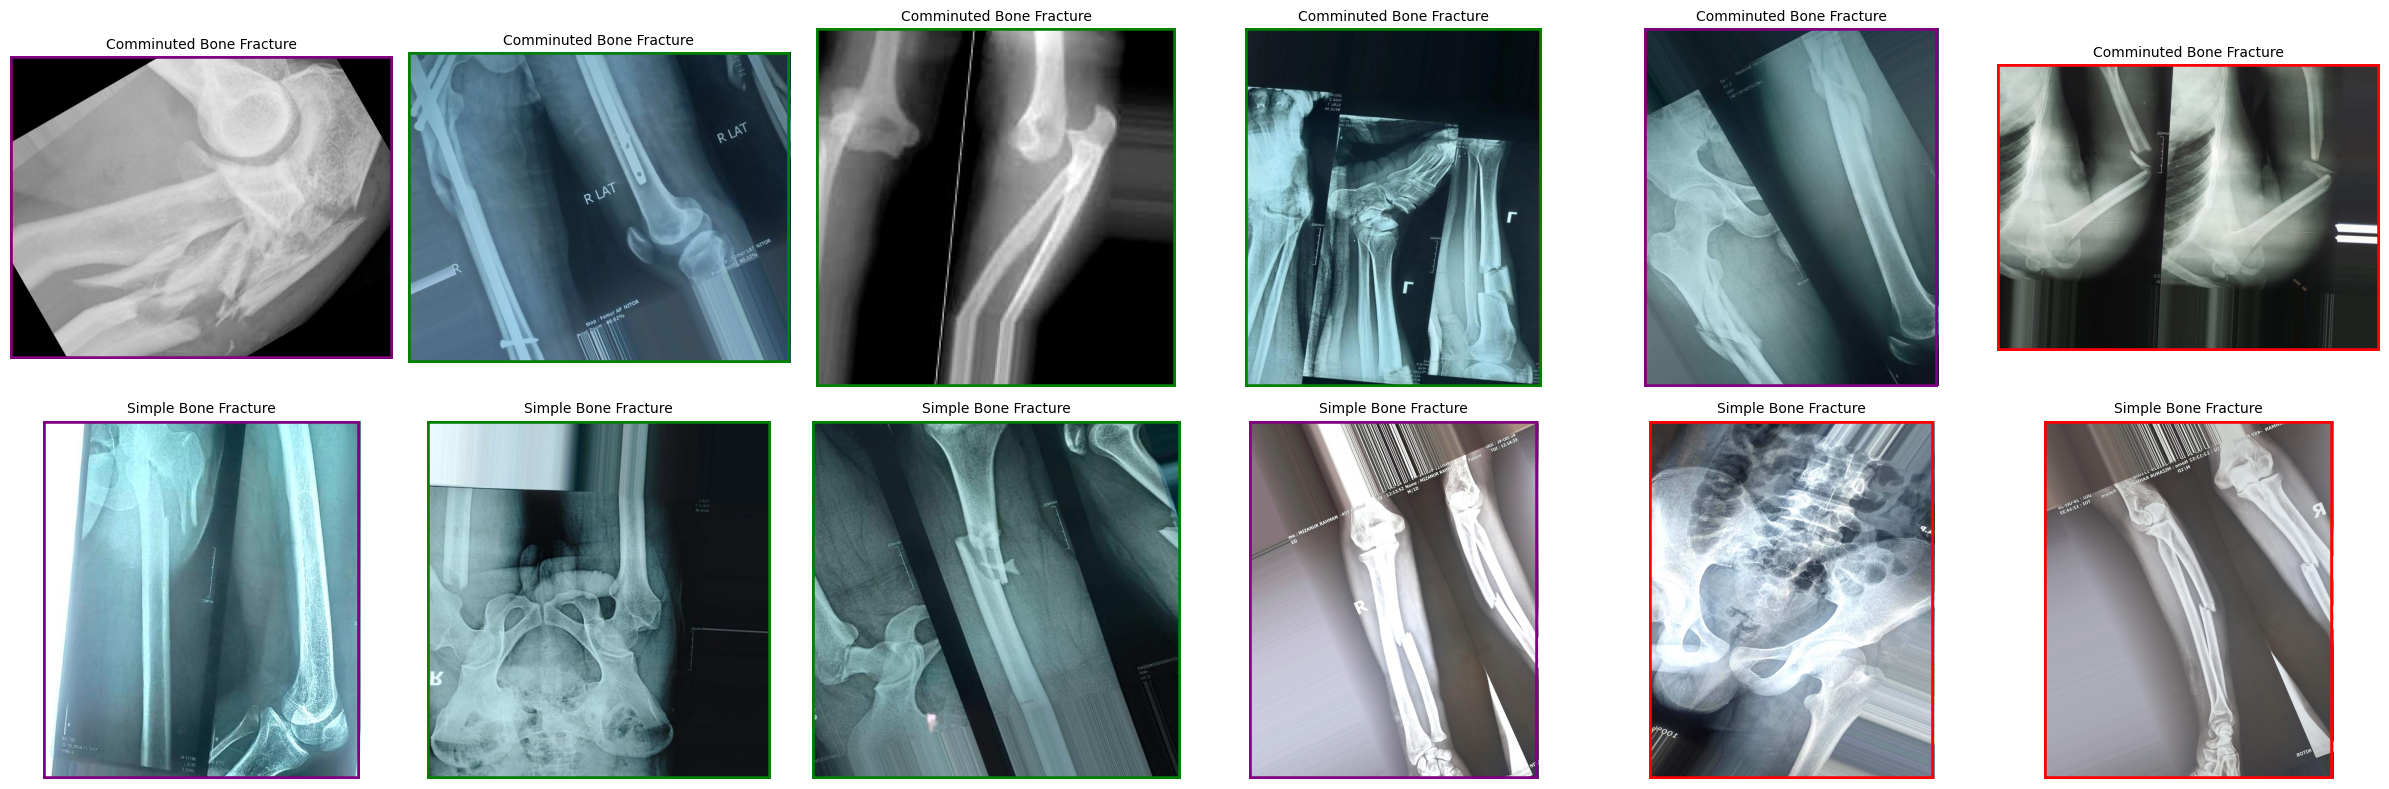

In [11]:
plot_class_samples(df,6)

In [12]:
label_mapping = {
    'Comminuted Bone Fracture': 0,
    'Simple Bone Fracture': 1,
}

df["label"] = df["label"].map(label_mapping)

print(df['label'].value_counts())
print(df.head())  

label
0    7366
1    6311
Name: count, dtype: int64
                                           file_path  label
0  /kaggle/input/simple-vs-comminuted-fractures-x...      0
1  /kaggle/input/simple-vs-comminuted-fractures-x...      0
2  /kaggle/input/simple-vs-comminuted-fractures-x...      0
3  /kaggle/input/simple-vs-comminuted-fractures-x...      0
4  /kaggle/input/simple-vs-comminuted-fractures-x...      0


In [14]:
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify = df['label'])
test_df, valid_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify = temp_df['label'])

print("Training set shapes:", train_df.shape)
print("Testing set shapes:", test_df.shape)
print("Validation set shapes:", valid_df.shape)

total = len(df)
print(f"Train: %{len(train_df) / total * 100:.1f}")
print(f"Test: %{len(test_df) / total * 100:.1f}")
print(f"Validation: %{len(valid_df) / total * 100:.1f}")

Training set shapes: (10941, 2)
Testing set shapes: (1368, 2)
Validation set shapes: (1368, 2)
Train: %80.0
Test: %10.0
Validation: %10.0


## ⚙️ Dataset Preparation

In [16]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None, c_type="RGB"):
        self.dataframe = dataframe
        self.transform = transform
        self.c_type = c_type.upper()
        self.classes = dataframe['label'].unique()

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['file_path']
        label = self.dataframe.iloc[idx]['label']

        try:
            if self.c_type == "RGB":
                image = Image.open(img_path).convert('RGB')
            else:
                image = Image.open(img_path).convert('L')
        except Exception as e:
            print(f"Hata: {img_path} açılamadı - {e}")
            image = Image.new(self.c_type, (224, 224), 0)

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
# Train transform (PIL -> Tensor ayrımı düzgün yapılmalı)
train_transform = transforms.Compose([
    # PIL Image ile çalışan transform'lar
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    # PIL Image'i tensöre çevir
    transforms.ToTensor(),
    # Tensör ile çalışan transform'lar
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test/Validation transform
test_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
# Dataset ve DataLoader'lar
train_dataset = CustomImageDataset(train_df, transform=train_transform, c_type="RGB")
valid_dataset = CustomImageDataset(valid_df, transform=test_val_transform, c_type="RGB")
test_dataset = CustomImageDataset(test_df, transform=test_val_transform, c_type="RGB")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)


print(f"Train loader batch sayısı: {len(train_loader)}")
print(f"Validation loader batch sayısı: {len(valid_loader)}")
print(f"Test loader batch sayısı: {len(test_loader)}")

classes = train_df['label'].unique()
print("Sınıflar:", classes)

Train loader batch sayısı: 342
Validation loader batch sayısı: 43
Test loader batch sayısı: 43
Sınıflar: [0 1]


In [19]:
# load an example tensor
img,label = train_dataset[10]
print(img.shape,torch.min(img),torch.max(img))

torch.Size([3, 224, 224]) tensor(-2.1179) tensor(2.6400)


## 🧠 Model Setup & Loading

In [20]:
import timm
import torch
import torch.nn as nn

def get_efficientnet_model(num_classes=2, pretrained=True):
    # Modeli yükle, kendi sınıf katmanını geçici olarak tut
    model = timm.create_model('efficientnet_b0', pretrained=pretrained)

    # Özellik boyutunu al
    if hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        num_ftrs = model.classifier.in_features
    else:
        # Bazı timm modelleri için farklı isim olabilir (head, fc, vs.)
        num_ftrs = model.get_classifier().in_features

    # Yeni classifier ekle
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, num_classes)
    )

    return model

In [21]:
model = get_efficientnet_model(num_classes=2, pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [73]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224),device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
          Identity-2         [-1, 32, 112, 112]               0
              SiLU-3         [-1, 32, 112, 112]               0
    BatchNormAct2d-4         [-1, 32, 112, 112]              64
            Conv2d-5         [-1, 32, 112, 112]             288
          Identity-6         [-1, 32, 112, 112]               0
              SiLU-7         [-1, 32, 112, 112]               0
    BatchNormAct2d-8         [-1, 32, 112, 112]              64
          Identity-9         [-1, 32, 112, 112]               0
           Conv2d-10              [-1, 8, 1, 1]             264
             SiLU-11              [-1, 8, 1, 1]               0
           Conv2d-12             [-1, 32, 1, 1]             288
          Sigmoid-13             [-1, 32, 1, 1]               0
    SqueezeExcite-14         [-1, 32, 1

## 🚀 Model Training

In [44]:
class_counts = train_df['label'].value_counts()
class_weights = 1.0 / torch.tensor([class_counts[0], class_counts[1]], dtype=torch.float).to(device)
class_weights

tensor([0.0002, 0.0002], device='cuda:0')

Epoch 1/50: 100%|██████████| 342/342 [02:45<00:00,  2.07it/s, loss=0.516, acc=72.42%]


Epoch 1, Train Loss: 0.516, Train Accuracy: 72.42%, Train F1: 0.718, Train AUC: 0.812, Train Recall: 0.759, Train Precision: 0.680


Validation: 100%|██████████| 43/43 [00:14<00:00,  2.98it/s, loss=0.373, acc=81.87%]


Epoch 1, Valid Loss: 0.371, Valid Accuracy: 81.87%, Valid F1: 0.830, Valid AUC: 0.935, Valid Recall: 0.960, Valid Precision: 0.731


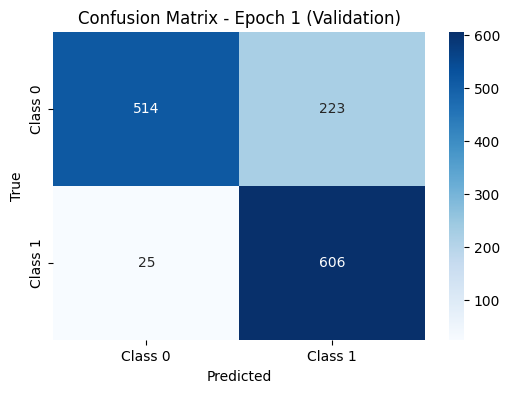

En iyi model kaydedildi: Valid Accuracy = 81.87%


Epoch 2/50: 100%|██████████| 342/342 [02:40<00:00,  2.13it/s, loss=0.359, acc=83.11%]


Epoch 2, Train Loss: 0.359, Train Accuracy: 83.11%, Train F1: 0.819, Train AUC: 0.918, Train Recall: 0.831, Train Precision: 0.809


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.24it/s, loss=0.249, acc=89.77%]


Epoch 2, Valid Loss: 0.248, Valid Accuracy: 89.77%, Valid F1: 0.893, Valid AUC: 0.964, Valid Recall: 0.922, Valid Precision: 0.865


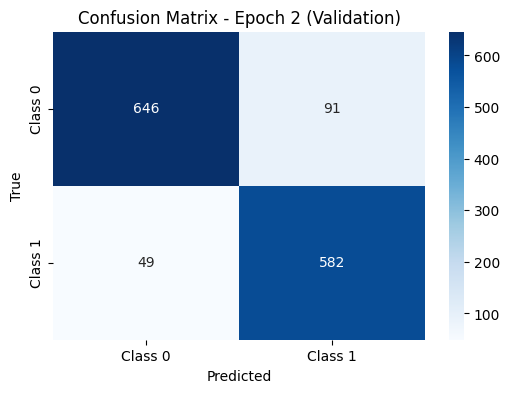

En iyi model kaydedildi: Valid Accuracy = 89.77%


Epoch 3/50: 100%|██████████| 342/342 [02:39<00:00,  2.14it/s, loss=0.264, acc=88.57%]


Epoch 3, Train Loss: 0.264, Train Accuracy: 88.57%, Train F1: 0.878, Train AUC: 0.957, Train Recall: 0.890, Train Precision: 0.866


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.17it/s, loss=0.125, acc=95.18%]


Epoch 3, Valid Loss: 0.124, Valid Accuracy: 95.18%, Valid F1: 0.947, Valid AUC: 0.991, Valid Recall: 0.941, Valid Precision: 0.953


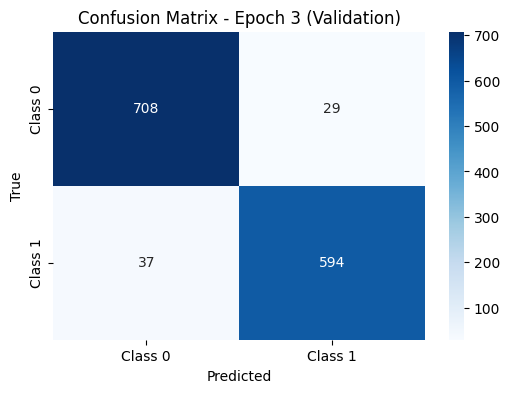

En iyi model kaydedildi: Valid Accuracy = 95.18%


Epoch 4/50: 100%|██████████| 342/342 [02:39<00:00,  2.14it/s, loss=0.193, acc=92.28%]


Epoch 4, Train Loss: 0.193, Train Accuracy: 92.28%, Train F1: 0.916, Train AUC: 0.977, Train Recall: 0.917, Train Precision: 0.916


Validation: 100%|██████████| 43/43 [00:14<00:00,  3.01it/s, loss=0.064, acc=97.22%]


Epoch 4, Valid Loss: 0.064, Valid Accuracy: 97.22%, Valid F1: 0.970, Valid AUC: 0.997, Valid Recall: 0.965, Valid Precision: 0.974


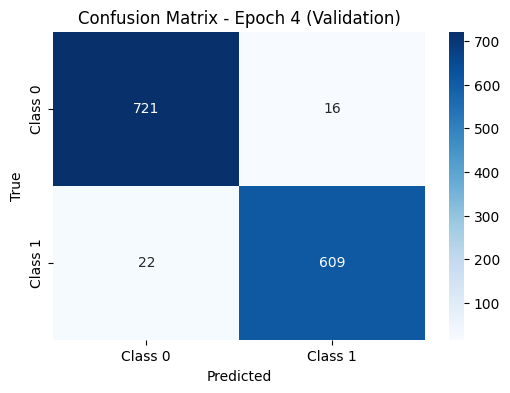

En iyi model kaydedildi: Valid Accuracy = 97.22%


Epoch 5/50: 100%|██████████| 342/342 [02:40<00:00,  2.13it/s, loss=0.156, acc=94.02%]


Epoch 5, Train Loss: 0.156, Train Accuracy: 94.02%, Train F1: 0.935, Train AUC: 0.985, Train Recall: 0.937, Train Precision: 0.934


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.19it/s, loss=0.044, acc=98.76%]


Epoch 5, Valid Loss: 0.044, Valid Accuracy: 98.76%, Valid F1: 0.987, Valid AUC: 0.999, Valid Recall: 0.995, Valid Precision: 0.978


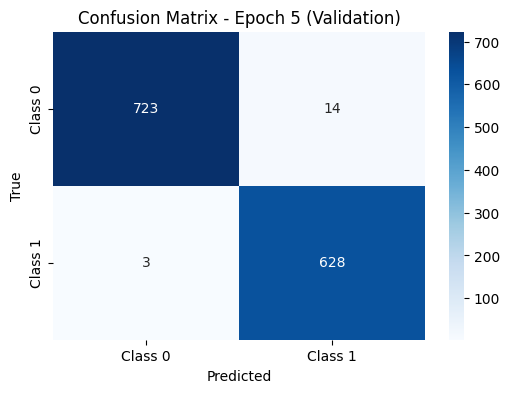

En iyi model kaydedildi: Valid Accuracy = 98.76%


Epoch 6/50: 100%|██████████| 342/342 [02:40<00:00,  2.13it/s, loss=0.131, acc=95.05%]


Epoch 6, Train Loss: 0.131, Train Accuracy: 95.05%, Train F1: 0.946, Train AUC: 0.989, Train Recall: 0.948, Train Precision: 0.945


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.22it/s, loss=0.060, acc=97.81%]


Epoch 6, Valid Loss: 0.060, Valid Accuracy: 97.81%, Valid F1: 0.977, Valid AUC: 0.998, Valid Recall: 0.990, Valid Precision: 0.963


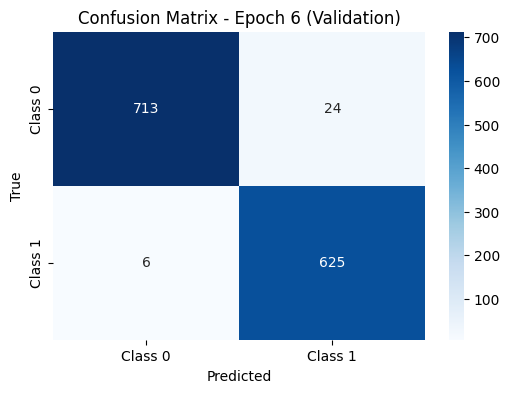

Erken durdurma sayacı: 1/20


Epoch 7/50: 100%|██████████| 342/342 [02:40<00:00,  2.14it/s, loss=0.113, acc=95.79%]


Epoch 7, Train Loss: 0.113, Train Accuracy: 95.79%, Train F1: 0.954, Train AUC: 0.992, Train Recall: 0.955, Train Precision: 0.953


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.09it/s, loss=0.071, acc=97.66%]


Epoch 7, Valid Loss: 0.070, Valid Accuracy: 97.66%, Valid F1: 0.975, Valid AUC: 0.998, Valid Recall: 0.992, Valid Precision: 0.959


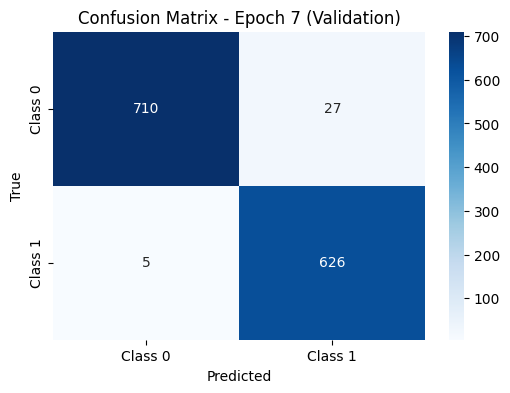

Erken durdurma sayacı: 2/20


Epoch 8/50: 100%|██████████| 342/342 [02:39<00:00,  2.14it/s, loss=0.104, acc=96.09%]


Epoch 8, Train Loss: 0.104, Train Accuracy: 96.09%, Train F1: 0.958, Train AUC: 0.993, Train Recall: 0.959, Train Precision: 0.956


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.19it/s, loss=0.028, acc=99.20%]


Epoch 8, Valid Loss: 0.028, Valid Accuracy: 99.20%, Valid F1: 0.991, Valid AUC: 0.999, Valid Recall: 0.994, Valid Precision: 0.989


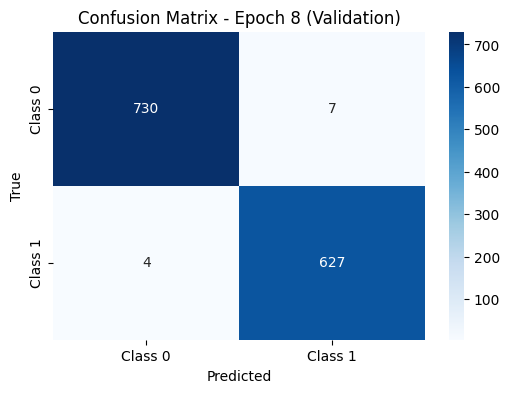

En iyi model kaydedildi: Valid Accuracy = 99.20%


Epoch 9/50: 100%|██████████| 342/342 [02:41<00:00,  2.12it/s, loss=0.093, acc=96.50%]


Epoch 9, Train Loss: 0.093, Train Accuracy: 96.50%, Train F1: 0.962, Train AUC: 0.995, Train Recall: 0.961, Train Precision: 0.963


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.21it/s, loss=0.060, acc=97.73%]


Epoch 9, Valid Loss: 0.060, Valid Accuracy: 97.73%, Valid F1: 0.976, Valid AUC: 0.997, Valid Recall: 0.984, Valid Precision: 0.967


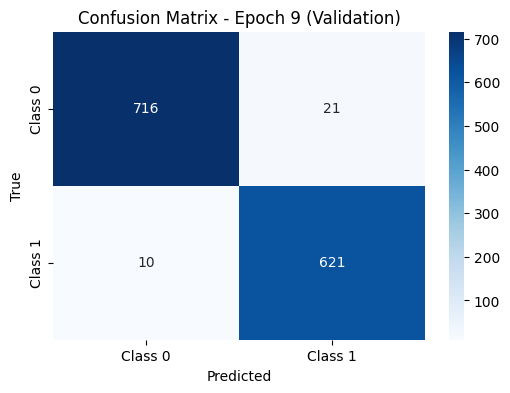

Erken durdurma sayacı: 1/20


Epoch 10/50: 100%|██████████| 342/342 [02:39<00:00,  2.14it/s, loss=0.078, acc=96.91%]


Epoch 10, Train Loss: 0.078, Train Accuracy: 96.91%, Train F1: 0.967, Train AUC: 0.996, Train Recall: 0.966, Train Precision: 0.967


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.13it/s, loss=0.014, acc=99.42%]


Epoch 10, Valid Loss: 0.014, Valid Accuracy: 99.42%, Valid F1: 0.994, Valid AUC: 1.000, Valid Recall: 0.995, Valid Precision: 0.992


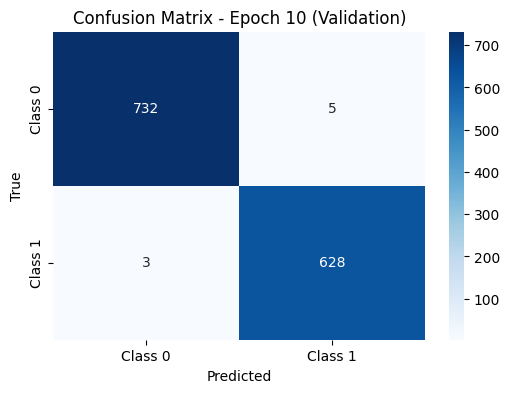

En iyi model kaydedildi: Valid Accuracy = 99.42%


Epoch 11/50: 100%|██████████| 342/342 [02:38<00:00,  2.15it/s, loss=0.082, acc=97.11%]


Epoch 11, Train Loss: 0.082, Train Accuracy: 97.11%, Train F1: 0.969, Train AUC: 0.996, Train Recall: 0.968, Train Precision: 0.969


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.08it/s, loss=0.034, acc=98.83%]


Epoch 11, Valid Loss: 0.034, Valid Accuracy: 98.83%, Valid F1: 0.987, Valid AUC: 1.000, Valid Recall: 0.997, Valid Precision: 0.978


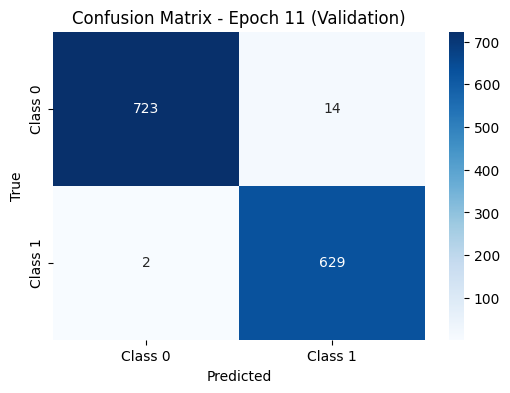

Erken durdurma sayacı: 1/20


Epoch 12/50: 100%|██████████| 342/342 [02:40<00:00,  2.13it/s, loss=0.087, acc=96.81%]


Epoch 12, Train Loss: 0.087, Train Accuracy: 96.81%, Train F1: 0.965, Train AUC: 0.995, Train Recall: 0.967, Train Precision: 0.964


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.19it/s, loss=0.029, acc=98.76%]


Epoch 12, Valid Loss: 0.028, Valid Accuracy: 98.76%, Valid F1: 0.986, Valid AUC: 0.999, Valid Recall: 0.984, Valid Precision: 0.989


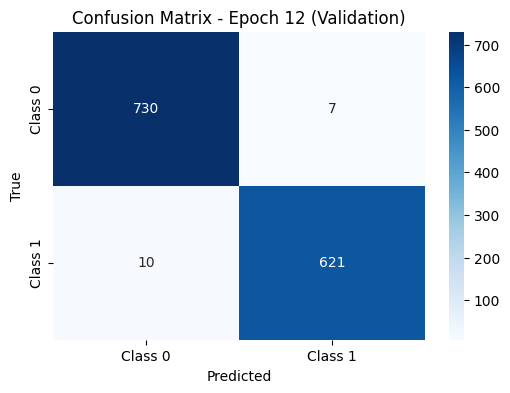

Erken durdurma sayacı: 2/20


Epoch 13/50: 100%|██████████| 342/342 [02:45<00:00,  2.07it/s, loss=0.077, acc=97.17%]


Epoch 13, Train Loss: 0.077, Train Accuracy: 97.17%, Train F1: 0.969, Train AUC: 0.996, Train Recall: 0.969, Train Precision: 0.969


Validation: 100%|██████████| 43/43 [00:14<00:00,  3.04it/s, loss=0.020, acc=99.56%]


Epoch 13, Valid Loss: 0.020, Valid Accuracy: 99.56%, Valid F1: 0.995, Valid AUC: 1.000, Valid Recall: 0.997, Valid Precision: 0.994


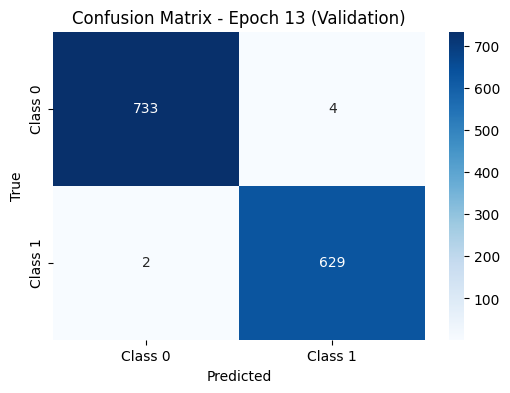

En iyi model kaydedildi: Valid Accuracy = 99.56%


Epoch 14/50: 100%|██████████| 342/342 [02:40<00:00,  2.13it/s, loss=0.058, acc=97.93%]


Epoch 14, Train Loss: 0.058, Train Accuracy: 97.93%, Train F1: 0.978, Train AUC: 0.998, Train Recall: 0.978, Train Precision: 0.977


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.25it/s, loss=0.011, acc=99.49%]


Epoch 14, Valid Loss: 0.011, Valid Accuracy: 99.49%, Valid F1: 0.994, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.991


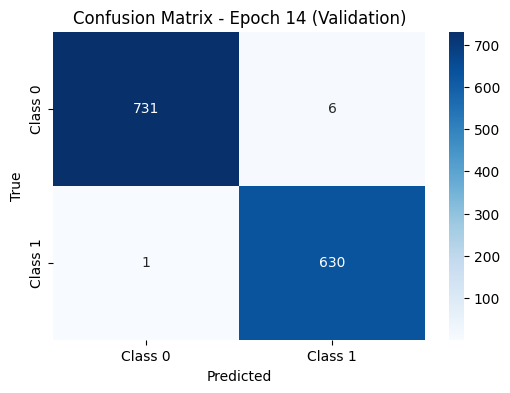

Erken durdurma sayacı: 1/20


Epoch 15/50: 100%|██████████| 342/342 [02:44<00:00,  2.08it/s, loss=0.058, acc=97.92%]


Epoch 15, Train Loss: 0.058, Train Accuracy: 97.92%, Train F1: 0.977, Train AUC: 0.998, Train Recall: 0.977, Train Precision: 0.978


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.15it/s, loss=0.007, acc=99.85%] 


Epoch 15, Valid Loss: 0.007, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.998


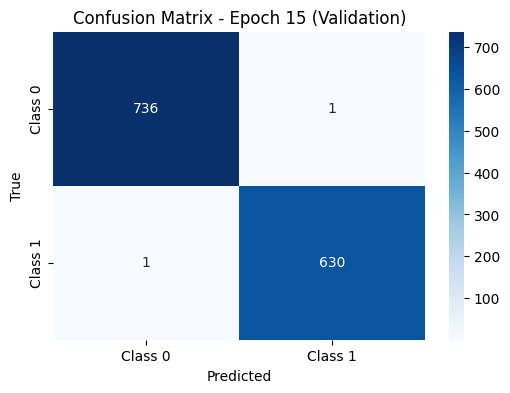

En iyi model kaydedildi: Valid Accuracy = 99.85%


Epoch 16/50: 100%|██████████| 342/342 [02:43<00:00,  2.10it/s, loss=0.064, acc=97.59%]


Epoch 16, Train Loss: 0.064, Train Accuracy: 97.59%, Train F1: 0.974, Train AUC: 0.997, Train Recall: 0.972, Train Precision: 0.975


Validation: 100%|██████████| 43/43 [00:13<00:00,  3.10it/s, loss=0.039, acc=99.20%]


Epoch 16, Valid Loss: 0.039, Valid Accuracy: 99.20%, Valid F1: 0.991, Valid AUC: 1.000, Valid Recall: 1.000, Valid Precision: 0.983


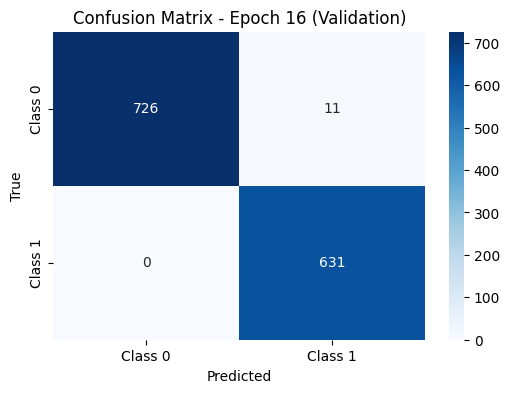

Erken durdurma sayacı: 1/20


Epoch 17/50: 100%|██████████| 342/342 [02:39<00:00,  2.14it/s, loss=0.047, acc=98.23%]


Epoch 17, Train Loss: 0.047, Train Accuracy: 98.23%, Train F1: 0.981, Train AUC: 0.999, Train Recall: 0.981, Train Precision: 0.981


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.31it/s, loss=0.014, acc=99.27%]


Epoch 17, Valid Loss: 0.014, Valid Accuracy: 99.27%, Valid F1: 0.992, Valid AUC: 1.000, Valid Recall: 0.995, Valid Precision: 0.989


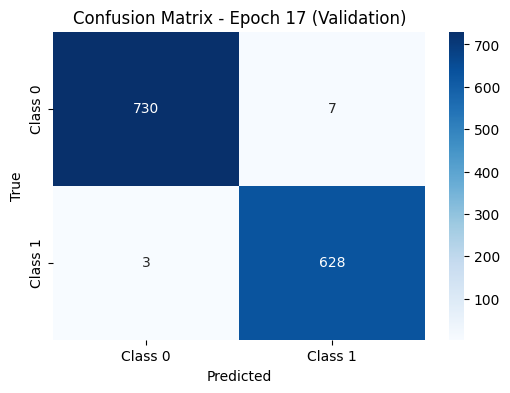

Erken durdurma sayacı: 2/20


Epoch 18/50: 100%|██████████| 342/342 [02:25<00:00,  2.35it/s, loss=0.061, acc=97.83%]


Epoch 18, Train Loss: 0.061, Train Accuracy: 97.83%, Train F1: 0.977, Train AUC: 0.998, Train Recall: 0.976, Train Precision: 0.977


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.64it/s, loss=0.011, acc=99.56%]


Epoch 18, Valid Loss: 0.011, Valid Accuracy: 99.56%, Valid F1: 0.995, Valid AUC: 1.000, Valid Recall: 0.994, Valid Precision: 0.997


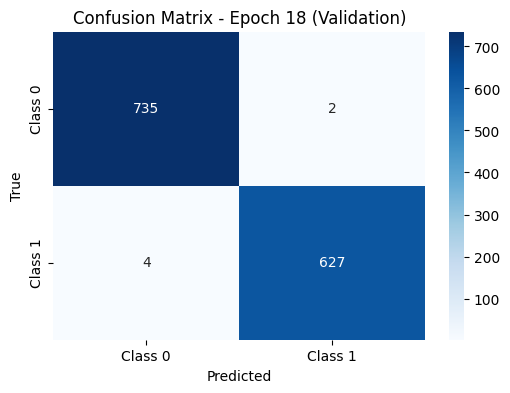

Erken durdurma sayacı: 3/20


Epoch 19/50: 100%|██████████| 342/342 [02:26<00:00,  2.34it/s, loss=0.052, acc=98.09%]


Epoch 19, Train Loss: 0.052, Train Accuracy: 98.09%, Train F1: 0.979, Train AUC: 0.998, Train Recall: 0.979, Train Precision: 0.979


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.68it/s, loss=0.018, acc=99.85%]


Epoch 19, Valid Loss: 0.018, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 0.999, Valid Recall: 1.000, Valid Precision: 0.997


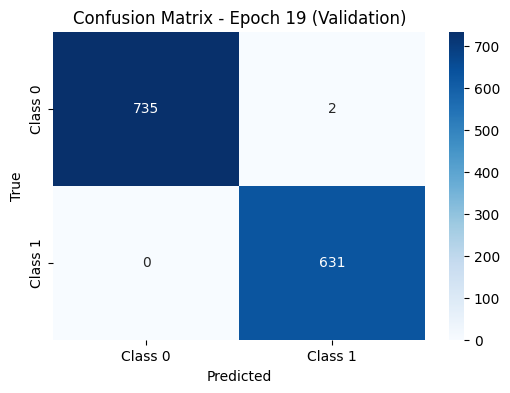

Erken durdurma sayacı: 4/20


Epoch 20/50: 100%|██████████| 342/342 [02:24<00:00,  2.37it/s, loss=0.053, acc=97.99%]


Epoch 20, Train Loss: 0.053, Train Accuracy: 97.99%, Train F1: 0.978, Train AUC: 0.998, Train Recall: 0.978, Train Precision: 0.978


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.45it/s, loss=0.009, acc=99.71%] 


Epoch 20, Valid Loss: 0.009, Valid Accuracy: 99.71%, Valid F1: 0.997, Valid AUC: 1.000, Valid Recall: 1.000, Valid Precision: 0.994


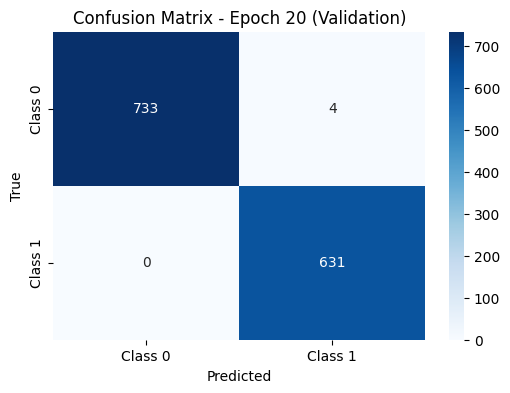

Erken durdurma sayacı: 5/20


Epoch 21/50: 100%|██████████| 342/342 [02:24<00:00,  2.37it/s, loss=0.047, acc=98.24%]


Epoch 21, Train Loss: 0.047, Train Accuracy: 98.24%, Train F1: 0.981, Train AUC: 0.999, Train Recall: 0.981, Train Precision: 0.980


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.72it/s, loss=0.004, acc=100.00%]


Epoch 21, Valid Loss: 0.004, Valid Accuracy: 100.00%, Valid F1: 1.000, Valid AUC: 1.000, Valid Recall: 1.000, Valid Precision: 1.000


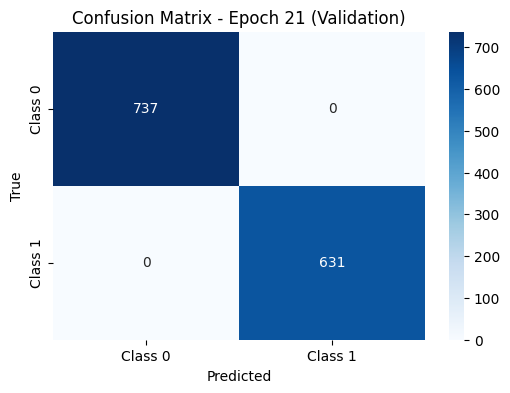

En iyi model kaydedildi: Valid Accuracy = 100.00%


Epoch 22/50: 100%|██████████| 342/342 [02:26<00:00,  2.34it/s, loss=0.047, acc=98.29%]


Epoch 22, Train Loss: 0.047, Train Accuracy: 98.29%, Train F1: 0.981, Train AUC: 0.998, Train Recall: 0.982, Train Precision: 0.981


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.65it/s, loss=0.012, acc=99.63%]


Epoch 22, Valid Loss: 0.012, Valid Accuracy: 99.63%, Valid F1: 0.996, Valid AUC: 1.000, Valid Recall: 0.997, Valid Precision: 0.995


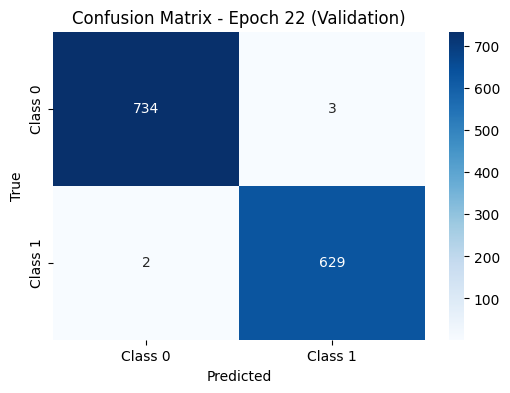

Erken durdurma sayacı: 1/20


Epoch 23/50: 100%|██████████| 342/342 [02:25<00:00,  2.35it/s, loss=0.044, acc=98.46%]


Epoch 23, Train Loss: 0.044, Train Accuracy: 98.46%, Train F1: 0.983, Train AUC: 0.999, Train Recall: 0.983, Train Precision: 0.984


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.70it/s, loss=0.006, acc=99.78%]


Epoch 23, Valid Loss: 0.006, Valid Accuracy: 99.78%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.997


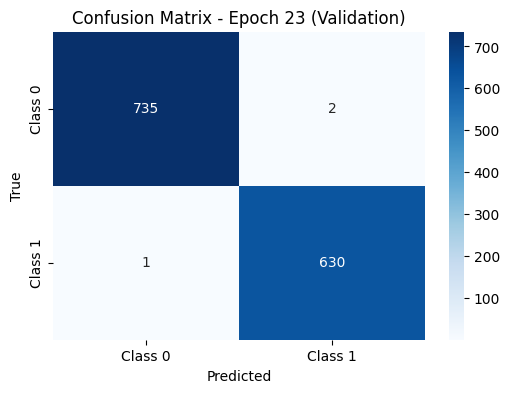

Erken durdurma sayacı: 2/20


Epoch 24/50: 100%|██████████| 342/342 [02:25<00:00,  2.35it/s, loss=0.042, acc=98.42%]


Epoch 24, Train Loss: 0.042, Train Accuracy: 98.42%, Train F1: 0.983, Train AUC: 0.999, Train Recall: 0.984, Train Precision: 0.982


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.69it/s, loss=0.014, acc=99.42%]


Epoch 24, Valid Loss: 0.014, Valid Accuracy: 99.42%, Valid F1: 0.994, Valid AUC: 1.000, Valid Recall: 1.000, Valid Precision: 0.987


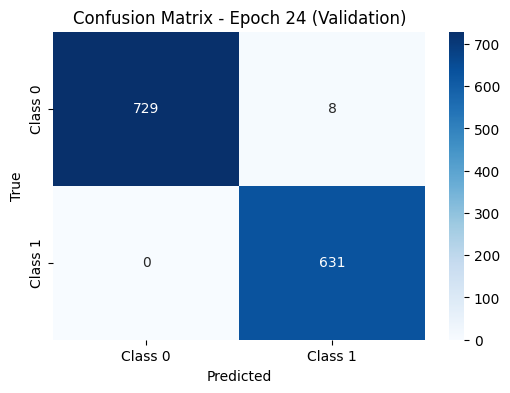

Erken durdurma sayacı: 3/20


Epoch 25/50: 100%|██████████| 342/342 [02:25<00:00,  2.35it/s, loss=0.048, acc=98.35%]


Epoch 25, Train Loss: 0.048, Train Accuracy: 98.35%, Train F1: 0.982, Train AUC: 0.998, Train Recall: 0.984, Train Precision: 0.980


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.47it/s, loss=0.010, acc=99.71%]


Epoch 25, Valid Loss: 0.010, Valid Accuracy: 99.71%, Valid F1: 0.997, Valid AUC: 1.000, Valid Recall: 0.995, Valid Precision: 0.998


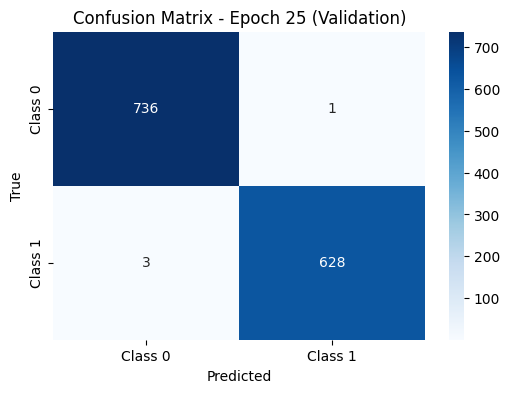

Erken durdurma sayacı: 4/20


Epoch 26/50: 100%|██████████| 342/342 [02:26<00:00,  2.34it/s, loss=0.034, acc=98.71%]


Epoch 26, Train Loss: 0.034, Train Accuracy: 98.71%, Train F1: 0.986, Train AUC: 0.999, Train Recall: 0.986, Train Precision: 0.986


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.53it/s, loss=0.013, acc=99.63%]


Epoch 26, Valid Loss: 0.013, Valid Accuracy: 99.63%, Valid F1: 0.996, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.994


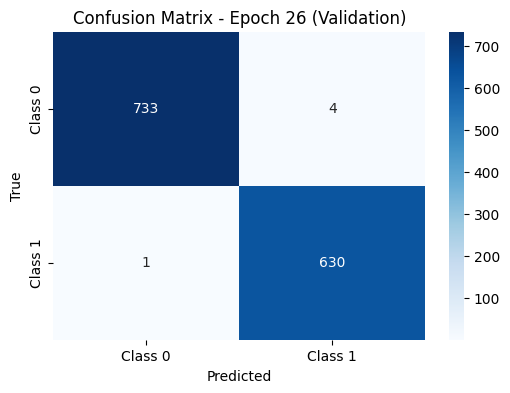

Erken durdurma sayacı: 5/20


Epoch 27/50: 100%|██████████| 342/342 [02:26<00:00,  2.33it/s, loss=0.042, acc=98.46%]


Epoch 27, Train Loss: 0.042, Train Accuracy: 98.46%, Train F1: 0.983, Train AUC: 0.999, Train Recall: 0.984, Train Precision: 0.983


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.58it/s, loss=0.017, acc=99.56%]


Epoch 27, Valid Loss: 0.017, Valid Accuracy: 99.56%, Valid F1: 0.995, Valid AUC: 1.000, Valid Recall: 0.990, Valid Precision: 1.000


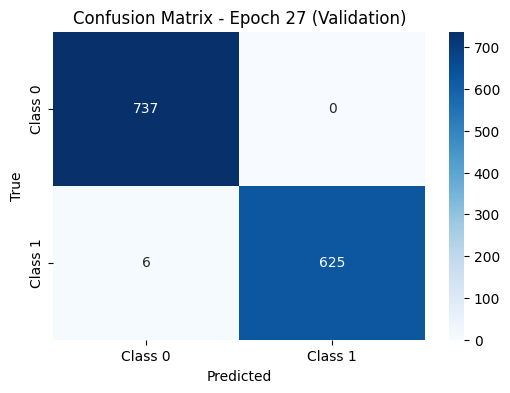

Erken durdurma sayacı: 6/20


Epoch 28/50: 100%|██████████| 342/342 [02:26<00:00,  2.33it/s, loss=0.041, acc=98.57%]


Epoch 28, Train Loss: 0.041, Train Accuracy: 98.57%, Train F1: 0.984, Train AUC: 0.999, Train Recall: 0.984, Train Precision: 0.985


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.60it/s, loss=0.005, acc=99.85%] 


Epoch 28, Valid Loss: 0.005, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.997, Valid Precision: 1.000


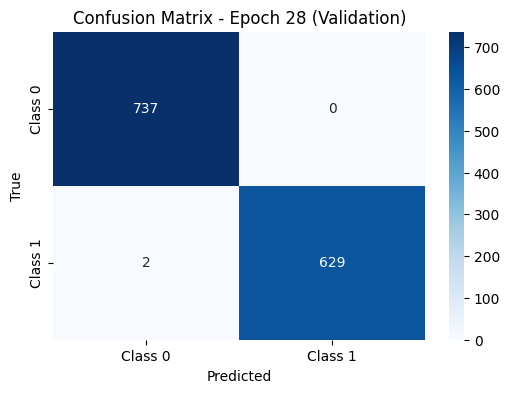

Erken durdurma sayacı: 7/20


Epoch 29/50: 100%|██████████| 342/342 [02:28<00:00,  2.31it/s, loss=0.043, acc=98.57%]


Epoch 29, Train Loss: 0.043, Train Accuracy: 98.57%, Train F1: 0.985, Train AUC: 0.999, Train Recall: 0.986, Train Precision: 0.984


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.64it/s, loss=0.008, acc=99.85%] 


Epoch 29, Valid Loss: 0.008, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.998


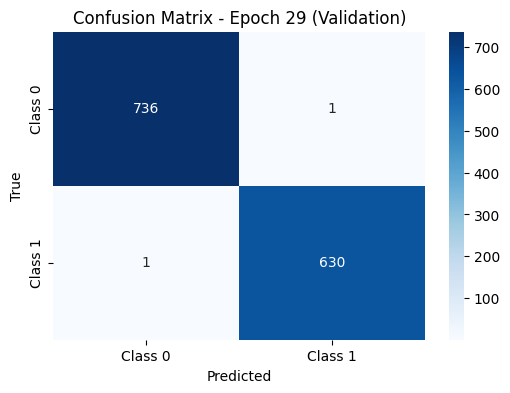

Erken durdurma sayacı: 8/20


Epoch 30/50: 100%|██████████| 342/342 [02:26<00:00,  2.33it/s, loss=0.042, acc=98.47%]


Epoch 30, Train Loss: 0.042, Train Accuracy: 98.47%, Train F1: 0.983, Train AUC: 0.999, Train Recall: 0.985, Train Precision: 0.982


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.63it/s, loss=0.007, acc=99.71%] 


Epoch 30, Valid Loss: 0.007, Valid Accuracy: 99.71%, Valid F1: 0.997, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.995


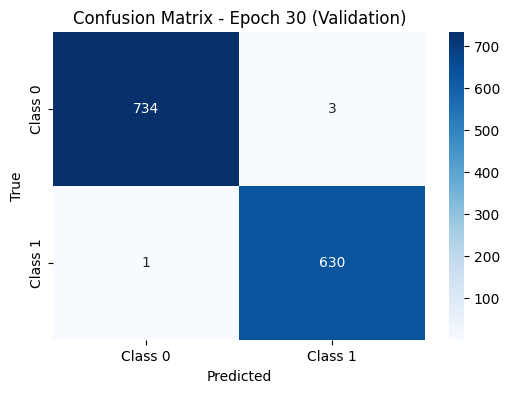

Erken durdurma sayacı: 9/20


Epoch 31/50: 100%|██████████| 342/342 [02:27<00:00,  2.32it/s, loss=0.032, acc=98.77%]


Epoch 31, Train Loss: 0.032, Train Accuracy: 98.77%, Train F1: 0.987, Train AUC: 0.999, Train Recall: 0.987, Train Precision: 0.987


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.66it/s, loss=0.011, acc=99.56%]


Epoch 31, Valid Loss: 0.011, Valid Accuracy: 99.56%, Valid F1: 0.995, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.992


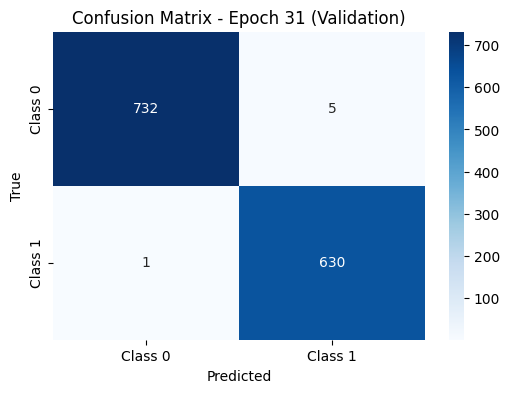

Erken durdurma sayacı: 10/20


Epoch 32/50: 100%|██████████| 342/342 [02:25<00:00,  2.34it/s, loss=0.030, acc=98.95%]


Epoch 32, Train Loss: 0.030, Train Accuracy: 98.95%, Train F1: 0.989, Train AUC: 0.999, Train Recall: 0.987, Train Precision: 0.990


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.53it/s, loss=0.003, acc=99.85%] 


Epoch 32, Valid Loss: 0.003, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.998


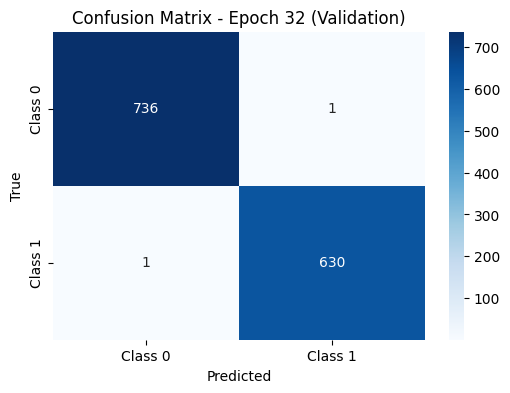

Erken durdurma sayacı: 11/20


Epoch 33/50: 100%|██████████| 342/342 [02:27<00:00,  2.32it/s, loss=0.034, acc=98.82%]


Epoch 33, Train Loss: 0.034, Train Accuracy: 98.82%, Train F1: 0.987, Train AUC: 0.999, Train Recall: 0.988, Train Precision: 0.987


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.45it/s, loss=0.004, acc=99.93%] 


Epoch 33, Valid Loss: 0.004, Valid Accuracy: 99.93%, Valid F1: 0.999, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 1.000


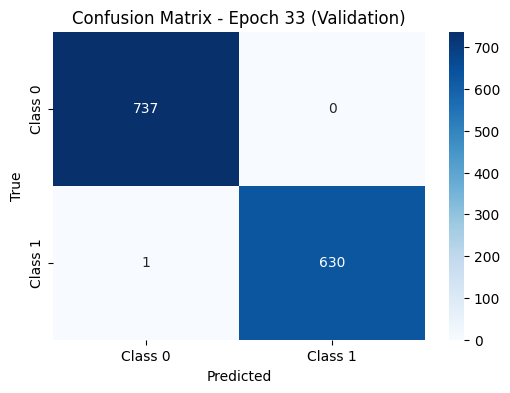

Erken durdurma sayacı: 12/20


Epoch 34/50: 100%|██████████| 342/342 [02:24<00:00,  2.36it/s, loss=0.031, acc=98.78%]


Epoch 34, Train Loss: 0.031, Train Accuracy: 98.78%, Train F1: 0.987, Train AUC: 0.999, Train Recall: 0.987, Train Precision: 0.987


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.47it/s, loss=0.001, acc=100.00%]


Epoch 34, Valid Loss: 0.001, Valid Accuracy: 100.00%, Valid F1: 1.000, Valid AUC: 1.000, Valid Recall: 1.000, Valid Precision: 1.000


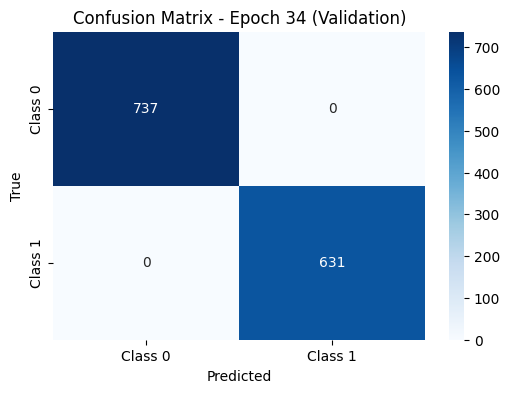

Erken durdurma sayacı: 13/20


Epoch 35/50: 100%|██████████| 342/342 [02:25<00:00,  2.35it/s, loss=0.038, acc=98.72%]


Epoch 35, Train Loss: 0.038, Train Accuracy: 98.72%, Train F1: 0.986, Train AUC: 0.999, Train Recall: 0.985, Train Precision: 0.987


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.69it/s, loss=0.018, acc=99.49%]


Epoch 35, Valid Loss: 0.018, Valid Accuracy: 99.49%, Valid F1: 0.994, Valid AUC: 1.000, Valid Recall: 0.989, Valid Precision: 1.000


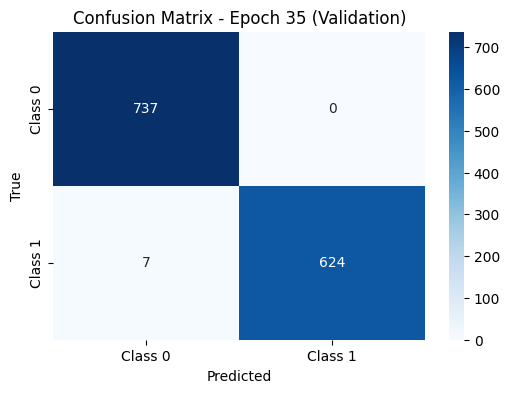

Erken durdurma sayacı: 14/20


Epoch 36/50: 100%|██████████| 342/342 [02:25<00:00,  2.35it/s, loss=0.036, acc=98.69%]


Epoch 36, Train Loss: 0.036, Train Accuracy: 98.69%, Train F1: 0.986, Train AUC: 0.999, Train Recall: 0.984, Train Precision: 0.987


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.64it/s, loss=0.003, acc=99.85%]


Epoch 36, Valid Loss: 0.003, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.998


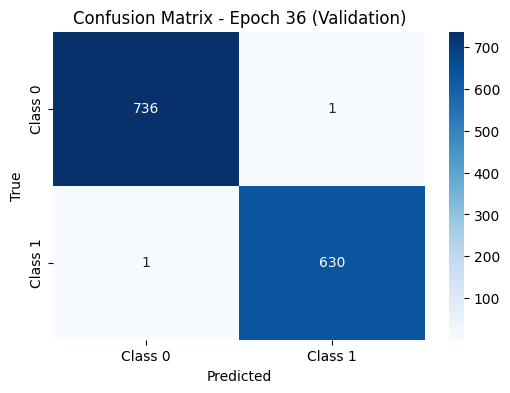

Erken durdurma sayacı: 15/20


Epoch 37/50: 100%|██████████| 342/342 [02:26<00:00,  2.33it/s, loss=0.024, acc=99.02%]


Epoch 37, Train Loss: 0.024, Train Accuracy: 99.02%, Train F1: 0.989, Train AUC: 1.000, Train Recall: 0.989, Train Precision: 0.990


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.63it/s, loss=0.007, acc=99.78%] 


Epoch 37, Valid Loss: 0.007, Valid Accuracy: 99.78%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.995, Valid Precision: 1.000


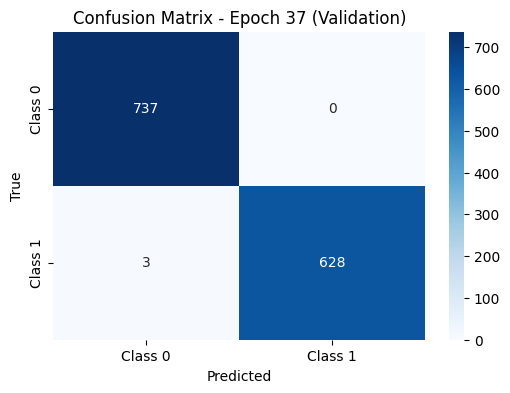

Erken durdurma sayacı: 16/20


Epoch 38/50: 100%|██████████| 342/342 [02:27<00:00,  2.32it/s, loss=0.026, acc=99.10%]


Epoch 38, Train Loss: 0.026, Train Accuracy: 99.10%, Train F1: 0.990, Train AUC: 0.999, Train Recall: 0.990, Train Precision: 0.990


Validation: 100%|██████████| 43/43 [00:11<00:00,  3.71it/s, loss=0.003, acc=99.85%]


Epoch 38, Valid Loss: 0.003, Valid Accuracy: 99.85%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.998


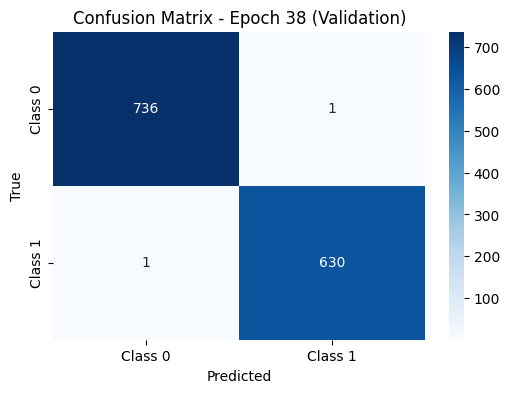

Erken durdurma sayacı: 17/20


Epoch 39/50: 100%|██████████| 342/342 [02:26<00:00,  2.34it/s, loss=0.027, acc=99.07%]


Epoch 39, Train Loss: 0.027, Train Accuracy: 99.07%, Train F1: 0.990, Train AUC: 1.000, Train Recall: 0.990, Train Precision: 0.990


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.49it/s, loss=0.006, acc=99.78%] 


Epoch 39, Valid Loss: 0.005, Valid Accuracy: 99.78%, Valid F1: 0.998, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 0.997


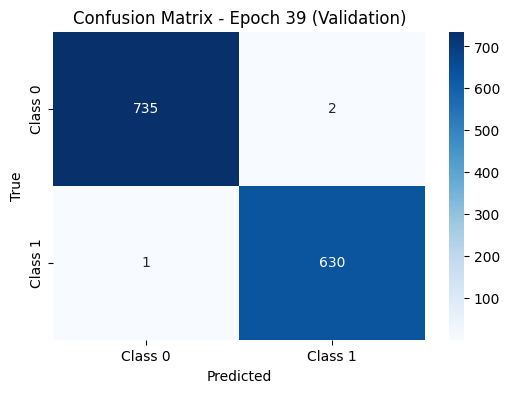

Erken durdurma sayacı: 18/20


Epoch 40/50: 100%|██████████| 342/342 [02:29<00:00,  2.29it/s, loss=0.025, acc=99.16%]


Epoch 40, Train Loss: 0.025, Train Accuracy: 99.16%, Train F1: 0.991, Train AUC: 1.000, Train Recall: 0.992, Train Precision: 0.990


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.44it/s, loss=0.002, acc=99.93%] 


Epoch 40, Valid Loss: 0.002, Valid Accuracy: 99.93%, Valid F1: 0.999, Valid AUC: 1.000, Valid Recall: 0.998, Valid Precision: 1.000


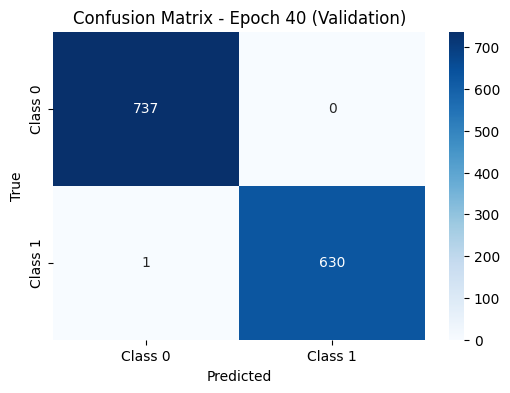

Erken durdurma sayacı: 19/20


Epoch 41/50: 100%|██████████| 342/342 [02:29<00:00,  2.29it/s, loss=0.031, acc=98.95%]


Epoch 41, Train Loss: 0.031, Train Accuracy: 98.95%, Train F1: 0.989, Train AUC: 0.999, Train Recall: 0.989, Train Precision: 0.989


Validation: 100%|██████████| 43/43 [00:12<00:00,  3.52it/s, loss=0.015, acc=99.56%]


Epoch 41, Valid Loss: 0.015, Valid Accuracy: 99.56%, Valid F1: 0.995, Valid AUC: 1.000, Valid Recall: 0.997, Valid Precision: 0.994


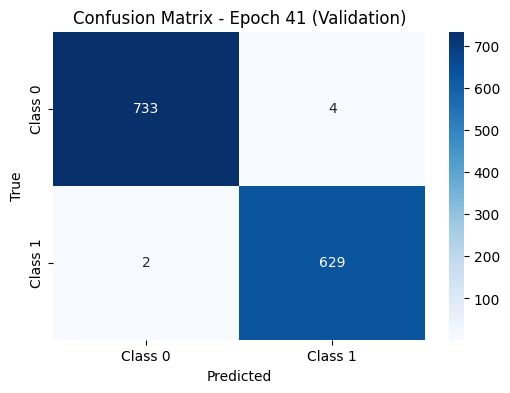

Erken durdurma sayacı: 20/20
Erken durdurma tetiklendi! 20 epoch boyunca iyileşme olmadı.
Eğitim tamamlandı!


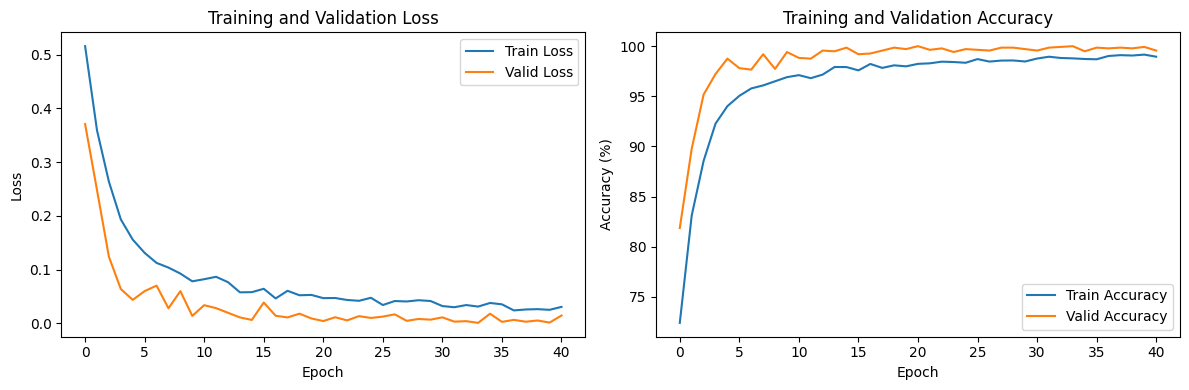

In [22]:
# TensorBoard writer'ı başlat
writer = SummaryWriter('runs/experiment_1')

# Kayıp ve optimizasyon
# criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=class_weights) # class_weights ile birlikte
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Erken durdurma ve model kaydetme için değişkenler
best_valid_acc = 0.0
best_model_path = 'best_model.pt'
patience = 20
early_stop_counter = 0

# Grafik için listeler
train_losses = []
valid_losses = []
train_accs = []
valid_accs = []

# Eğitim döngüsü
num_epochs = 50

for epoch in range(num_epochs):
    # Eğitim aşaması
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    all_labels_train = []
    all_preds_train = []
    all_probs_train = []

    train_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{num_epochs}")
    for i, (images, labels) in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        probs = F.softmax(outputs, dim=1)[:, 1]
        total_train += labels.size(0)
        correct_train += (preds == labels).sum().item()
        all_labels_train.extend(labels.detach().cpu().numpy())
        all_preds_train.extend(preds.detach().cpu().numpy())
        all_probs_train.extend(probs.detach().cpu().numpy())

        train_loss_avg = running_loss / (i + 1)
        train_accuracy = 100 * correct_train / total_train
        train_bar.set_postfix({'loss': f'{train_loss_avg:.3f}', 'acc': f'{train_accuracy:.2f}%'})

    train_f1 = f1_score(all_labels_train, all_preds_train)
    train_auc = roc_auc_score(all_labels_train, all_probs_train)
    train_recall = recall_score(all_labels_train, all_preds_train)
    train_precision = precision_score(all_labels_train, all_preds_train)
    train_loss_avg = running_loss / len(train_loader)
    train_losses.append(train_loss_avg)
    train_accs.append(train_accuracy)

    # TensorBoard'a train metriklerini kaydet
    writer.add_scalar('Loss/Train', train_loss_avg, epoch)
    writer.add_scalar('Accuracy/Train', train_accuracy, epoch)
    writer.add_scalar('F1/Train', train_f1, epoch)
    writer.add_scalar('AUC/Train', train_auc, epoch)
    writer.add_scalar('Recall/Train', train_recall, epoch)
    writer.add_scalar('Precision/Train', train_precision, epoch)

    print(f'Epoch {epoch + 1}, Train Loss: {train_loss_avg:.3f}, Train Accuracy: {train_accuracy:.2f}%, '
          f'Train F1: {train_f1:.3f}, Train AUC: {train_auc:.3f}, Train Recall: {train_recall:.3f}, '
          f'Train Precision: {train_precision:.3f}')

    # Doğrulama aşaması
    model.eval()
    valid_loss = 0.0
    correct_valid = 0
    total_valid = 0
    all_labels_valid = []
    all_preds_valid = []
    all_probs_valid = []

    with torch.no_grad():
        valid_bar = tqdm(valid_loader, total=len(valid_loader), desc="Validation")
        for images, labels in valid_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            valid_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            probs = F.softmax(outputs, dim=1)[:, 1]
            total_valid += labels.size(0)
            correct_valid += (preds == labels).sum().item()
            all_labels_valid.extend(labels.detach().cpu().numpy())
            all_preds_valid.extend(preds.detach().cpu().numpy())
            all_probs_valid.extend(probs.detach().cpu().numpy())

            valid_loss_avg = valid_loss / (len(valid_loader.dataset) / valid_loader.batch_size)
            valid_accuracy = 100 * correct_valid / total_valid
            valid_bar.set_postfix({'loss': f'{valid_loss_avg:.3f}', 'acc': f'{valid_accuracy:.2f}%'})

    valid_f1 = f1_score(all_labels_valid, all_preds_valid)
    valid_auc = roc_auc_score(all_labels_valid, all_probs_valid)
    valid_recall = recall_score(all_labels_valid, all_preds_valid)
    valid_precision = precision_score(all_labels_valid, all_preds_valid)
    valid_loss_avg = valid_loss / len(valid_loader)
    valid_losses.append(valid_loss_avg)
    valid_accs.append(valid_accuracy)


    # TensorBoard'a valid metriklerini kaydet
    writer.add_scalar('Loss/Valid', valid_loss_avg, epoch)
    writer.add_scalar('Accuracy/Valid', valid_accuracy, epoch)
    writer.add_scalar('F1/Valid', valid_f1, epoch)
    writer.add_scalar('AUC/Valid', valid_auc, epoch)
    writer.add_scalar('Recall/Valid', valid_recall, epoch)
    writer.add_scalar('Precision/Valid', valid_precision, epoch)

    print(f'Epoch {epoch + 1}, Valid Loss: {valid_loss_avg:.3f}, Valid Accuracy: {valid_accuracy:.2f}%, '
          f'Valid F1: {valid_f1:.3f}, Valid AUC: {valid_auc:.3f}, Valid Recall: {valid_recall:.3f}, '
          f'Valid Precision: {valid_precision:.3f}')

    # Confusion Matrix çizimi (Validation için)
    cm = confusion_matrix(all_labels_valid, all_preds_valid)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f'Confusion Matrix - Epoch {epoch + 1} (Validation)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # En iyi modeli kaydet
    if valid_accuracy > best_valid_acc:
        best_valid_acc = valid_accuracy
        torch.save(model.state_dict(), best_model_path)
        print(f"En iyi model kaydedildi: Valid Accuracy = {best_valid_acc:.2f}%")
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"Erken durdurma sayacı: {early_stop_counter}/{patience}")

        stop_training = input("Eğitimi durdurmak ister misiniz? (e/h/evet/hayır/yes/no): ").strip().lower()

        yes_answers = {"e", "evet", "yes", "y"}
        no_answers = {"h", "hayır", "no", "n"}

        if stop_training in yes_answers:
            print("Eğitim kullanıcı tarafından durduruldu!")
            break
        elif stop_training in no_answers:
            print("Eğitime devam ediliyor...")
        else:
            print(("Geçersiz giriş, varsayılan olarak eğitime devam ediliyor..."))

    # Model checkpointing (her epoch sonunda kaydet)
    checkpoint_path = f'model_checkpoint_epoch_{epoch+1}.pt'
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss_avg,
        'valid_loss': valid_loss_avg,
        'valid_accuracy': valid_accuracy
    }, checkpoint_path)
    print(f"Checkpoint kaydedildi: {checkpoint_path}")


    # Erken durdurma
    if early_stop_counter >= patience:
        print(f"Erken durdurma tetiklendi! {patience} epoch boyunca iyileşme olmadı.")
        break

print('Eğitim tamamlandı!')


# TensorBoard writer'ı kapat
writer.close()


# Eğitim ve doğrulama kayıplarını grafikle
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Eğitim ve doğrulama doğruluklarını grafikle
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(valid_accs, label='Valid Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
best_model_path = '/kaggle/working/best_model.pt'  
model.load_state_dict(torch.load(best_model_path, weights_only=True))

## 📊 Model Evaluation

In [23]:
# Assuming criterion, model, device, test_loader, and valid_loader are defined
criterion = nn.CrossEntropyLoss()  # Ensure this is defined if not already

# Validation evaluation
model.eval()
correct_valid = 0
total_valid = 0
valid_loss = 0.0
all_valid_labels = []
all_valid_preds = []
all_valid_probs = []

with torch.no_grad():
    for images, labels in valid_loader:  # Assuming valid_loader is defined
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)  # Validation kaybı
        valid_loss += loss.item()
        
        _, preds = torch.max(outputs, 1)
        probs = F.softmax(outputs, dim=1)[:, 1]

        total_valid += labels.size(0)
        correct_valid += (preds == labels).sum().item()
        all_valid_labels.extend(labels.detach().cpu().numpy())
        all_valid_preds.extend(preds.detach().cpu().numpy())
        all_valid_probs.extend(probs.detach().cpu().numpy())

# Validation metrics
valid_loss = valid_loss / len(valid_loader)
valid_accuracy = 100 * correct_valid / total_valid
valid_f1 = f1_score(all_valid_labels, all_valid_preds)
valid_auc = roc_auc_score(all_valid_labels, all_valid_probs)
valid_precision = precision_score(all_valid_labels, all_valid_preds)
valid_recall = recall_score(all_valid_labels, all_valid_preds)

# Test evaluation
correct_test = 0
total_test = 0
test_loss = 0.0
all_test_labels = []
all_test_preds = []
all_test_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)  # Test kaybı
        test_loss += loss.item()
        
        _, preds = torch.max(outputs, 1)
        probs = F.softmax(outputs, dim=1)[:, 1]

        total_test += labels.size(0)
        correct_test += (preds == labels).sum().item()
        all_test_labels.extend(labels.detach().cpu().numpy())
        all_test_preds.extend(preds.detach().cpu().numpy())
        all_test_probs.extend(probs.detach().cpu().numpy())

# Test metrics
test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct_test / total_test
test_f1 = f1_score(all_test_labels, all_test_preds)
test_auc = roc_auc_score(all_test_labels, all_test_probs)
test_precision = precision_score(all_test_labels, all_test_preds)
test_recall = recall_score(all_test_labels, all_test_preds)

# Print all metrics
print("\nValidation Results:")
print(f'Validation Loss: {valid_loss:.3f}')
print(f'Validation Accuracy: {valid_accuracy:.2f}%')
print(f'Validation Precision: {valid_precision:.3f}')
print(f'Validation Recall: {valid_recall:.3f}')
print(f'Validation F1 Score: {valid_f1:.3f}')
print(f'Validation ROC AUC: {valid_auc:.3f}')

print("\nTest Results:")
print(f'Test Loss: {test_loss:.3f}')
print(f'Test Accuracy: {test_accuracy:.2f}%')
print(f'Test Precision: {test_precision:.3f}')
print(f'Test Recall: {test_recall:.3f}')
print(f'Test F1 Score: {test_f1:.3f}')
print(f'Test ROC AUC: {test_auc:.3f}')


Validation Results:
Validation Loss: 0.015
Validation Accuracy: 99.56%
Validation Precision: 0.994
Validation Recall: 0.997
Validation F1 Score: 0.995
Validation ROC AUC: 1.000

Test Results:
Test Loss: 0.021
Test Accuracy: 99.20%
Test Precision: 0.987
Test Recall: 0.995
Test F1 Score: 0.991
Test ROC AUC: 1.000


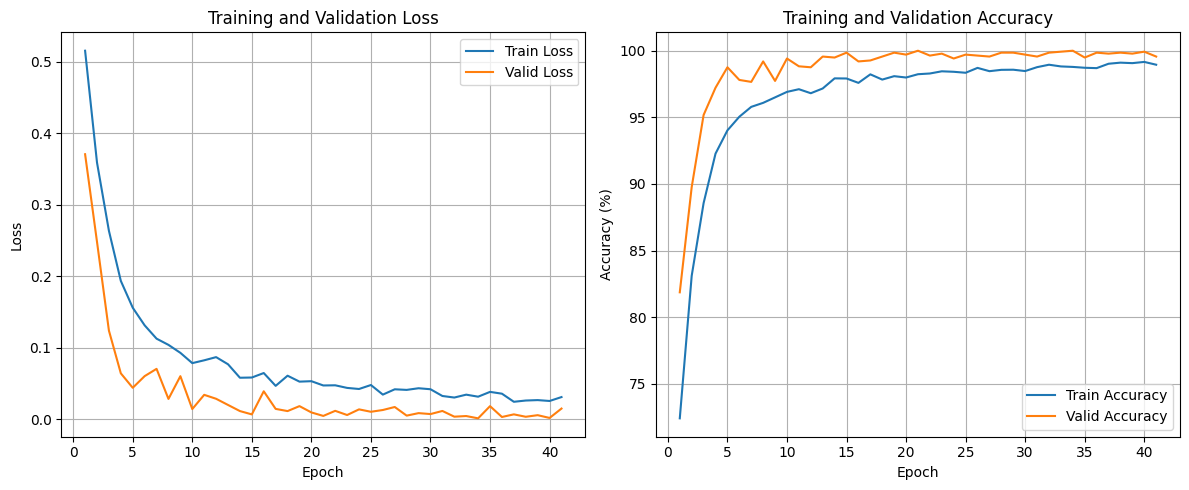

In [24]:
epochs_range = range(1, len(train_losses) + 1)  

# Loss grafiği
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, valid_losses, label='Valid Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

# Accuracy grafiği
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label='Train Accuracy')
plt.plot(epochs_range, valid_accs, label='Valid Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [27]:
print("\nClassification Report:")
print(classification_report(all_labels_train, all_preds_train, target_names=['Comminuted', 'Simple']))


Classification Report:
              precision    recall  f1-score   support

  Comminuted       0.99      0.99      0.99      5892
      Simple       0.99      0.99      0.99      5049

    accuracy                           0.99     10941
   macro avg       0.99      0.99      0.99     10941
weighted avg       0.99      0.99      0.99     10941



In [28]:
# Validation için Confusion Matrix
cm_valid = confusion_matrix(all_valid_labels, all_valid_preds)
print("\nValidation Confusion Matrix:")
print(cm_valid)

# Test için Confusion Matrix
cm_test = confusion_matrix(all_test_labels, all_test_preds)
print("\nTest Confusion Matrix:")
print(cm_test)


Validation Confusion Matrix:
[[733   4]
 [  2 629]]

Test Confusion Matrix:
[[729   8]
 [  3 628]]


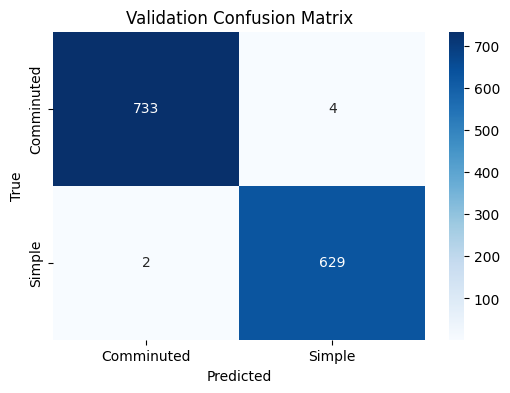

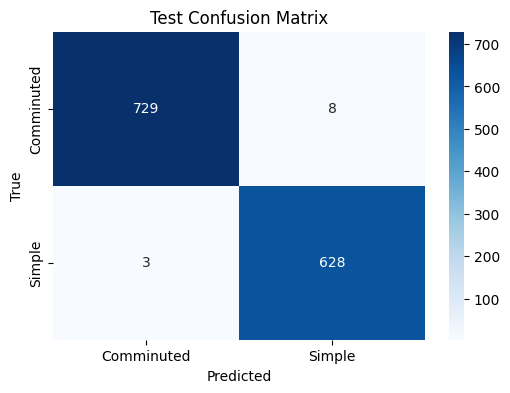

In [29]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_valid, annot=True, fmt='d', cmap='Blues', xticklabels=['Comminuted', 'Simple'], yticklabels=['Comminuted', 'Simple'])
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['Comminuted', 'Simple'], yticklabels=['Comminuted', 'Simple'])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

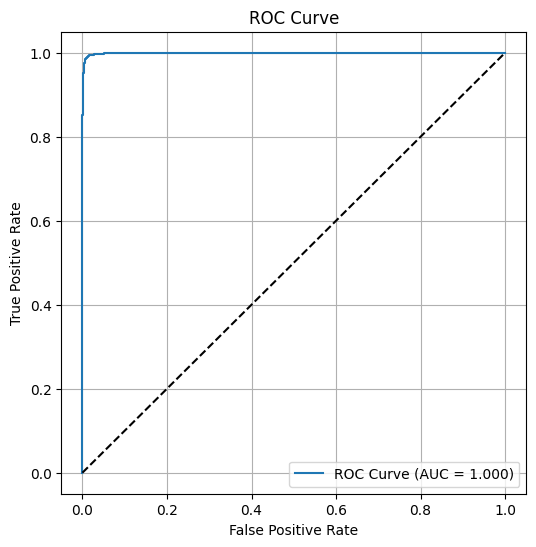

In [32]:
fpr, tpr, _ = roc_curve(all_labels_train, all_probs_train)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # Rastgele tahmin çizgisi
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.grid()
plt.show()

In [35]:
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import brier_score_loss
from sklearn.metrics import log_loss
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import fbeta_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import hamming_loss
from imblearn.metrics import geometric_mean_score
from scipy.stats import entropy


# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(all_labels_train, all_preds_train)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

accuracy = accuracy_score(all_labels_train, all_preds_train)
print(f"Accuracy: {accuracy:.4f}")

# Modelin pozitif tahminlerinin ne kadarının gerçekten doğru olduğunu gösterir.
precision = precision_score(all_labels_train, all_preds_train)
print(f"Precision: {precision:.4f}")

# Modelin gerçek pozitifleri ne kadar iyi tespit ettiğini gösterir.
recall = recall_score(all_labels_train, all_preds_train)
print(f"Recall: {recall:.4f}")

# Precision ve recall’ın dengeli bir kombinasyonudur.
f1 = f1_score(all_labels_train, all_preds_train)
print(f"F1 Score: {f1:.4f}")

# Rastgele tahminlere karşı modelin performansını değerlendirir.
kappa = cohen_kappa_score(all_labels_train, all_preds_train)
print(f"Cohen's Kappa Score: {kappa:.4f}")

# Modelin olasılık tahminlerinin ne kadar güvenilir olduğunu ölçer.
brier = brier_score_loss(all_labels_train, all_preds_train)
print(f"Brier Score: {brier:.4f}")

# Olasılık tahminlerinin ne kadar doğru olduğunu değerlendirir.
logloss = log_loss(all_labels_train, all_preds_train)
print(f"Log Loss: {logloss:.4f}")

# Negatif sınıfların doğru tahmin edilme oranıdır (True Negative Rate - TNR).
tn, fp, fn, tp = cm.ravel()  # Confusion Matrix değerlerini ayır
specificity = tn / (tn + fp)
print(f"Specificity ((Özgüllük)): {specificity:.4f}")

# Özellikle dengesiz veri kümeleri için, Accuracy yerine daha iyi bir alternatiftir.
balanced_acc = balanced_accuracy_score(all_labels_train, all_preds_train)
print(f"Balanced Accuracy: {balanced_acc:.4f}")

# F1-Score gibi ama recall’a (duyarlılık) daha fazla önem verir.
f2 = fbeta_score(all_labels_train, all_preds_train, beta=2)
print(f"F2 Score: {f2:.4f}")

# Özellikle sınıflandırma modellerinde sınıfların ne kadar kesiştiğini gösterir.
jaccard = jaccard_score(all_labels_train, all_preds_train)
print(f"Jaccard Index: {jaccard:.4f}")

# Modelin genel ayrım gücünü gösterir.
youden_j = recall + specificity - 1
print(f"Youden's J Statistic: {youden_j:.4f}")

# Yanlış sınıflandırılan örneklerin oranını gösterir.
hamming = hamming_loss(all_labels_train, all_preds_train)
print(f"Hamming Loss: {hamming:.4f}")

# Dengesiz veri kümelerinde hem sensitivity (recall) hem de specificity'yi dikkate alır.
gmean = geometric_mean_score(all_labels_train, all_preds_train)
print(f"G-Mean: {gmean:.4f}")


Matthews Correlation Coefficient (MCC): 0.9789
Accuracy: 0.9895
Precision: 0.9885
Recall: 0.9887
F1 Score: 0.9886
Cohen's Kappa Score: 0.9789
Brier Score: 0.0105
Log Loss: 0.3789
Specificity ((Özgüllük)): 0.9946
Balanced Accuracy: 0.9894
F2 Score: 0.9887
Jaccard Index: 0.9775
Youden's J Statistic: 0.9833
Hamming Loss: 0.0105
G-Mean: 0.9894


## 🧪 Inferance

In [37]:
from PIL import Image

image_path = '/kaggle/input/simple-vs-comminuted-fractures-x-ray-data/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture X-ray Dataset Simple vs. Comminuted Fractures/Bone Fracture/Bone Fracture/Orginal/Comminuted Bone Fracture/1000_Comminuted Bone Fracture.jpg'
image = Image.open(image_path).convert('RGB')
image = test_val_transform(image).unsqueeze(0)  # Batch boyutu ekleme

class_names = ['Comminuted', 'Simple']  

# Görüntü sınıflandırması
model.eval()
with torch.no_grad():
    image = image.to(device)
    output = model(image)

    # Softmax uygulayarak olasılıkları al
    probabilities = F.softmax(output, dim=1)
    
    class_prob, predicted = torch.max(probabilities, 1)
    class_idx = predicted.item()
    confidence = class_prob.item() * 100
    print(f"Tahmin edilen sınıf: {class_names[class_idx]} ({confidence:.2f}%)")

Tahmin edilen sınıf: Comminuted (99.93%)


## 🔍 GradCAM

In [40]:

# Grad-CAM fonksiyonu
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hook'ları kaydet
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_image, target_class=None):
        self.model.eval()
        input_image = input_image.unsqueeze(0).to(device)  # Batch boyutu ekle
        input_image.requires_grad = True  # Gradient takibini aç

        # Forward pass
        output = self.model(input_image)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        # Backward pass
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][target_class] = 1
        output.backward(gradient=one_hot)

        # Gradient ve aktivasyonları kullanarak heatmap hesapla
        gradients = self.gradients.mean(dim=(2, 3), keepdim=True)
        heatmap = F.relu((gradients * self.activations).sum(dim=1)).squeeze().cpu().numpy()
        
        # Heatmap'i normalize et
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap) + 1e-10  # Küçük bir epsilon ile sıfıra bölmeyi önle
        
        return heatmap, target_class

# Test değerlendirmesi ve Grad-CAM
def evaluate_and_visualize(model, test_loader, criterion, device, num_images_to_show=1):
    model.eval()
    correct_test = 0
    total_test = 0
    test_loss = 0.0
    all_test_labels = []
    all_test_preds = []
    all_test_probs = []

    # EfficientNet-B0 için son convolutional katman
    target_layer = model.conv_head  # EfficientNet-B0'da son conv katmanı
    grad_cam = GradCAM(model, target_layer)

    # Test metriklerini hesapla (gradient hesaplama kapalı)
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            probs = F.softmax(outputs, dim=1)[:, 1]

            total_test += labels.size(0)
            correct_test += (preds == labels).sum().item()
            all_test_labels.extend(labels.detach().cpu().numpy())
            all_test_preds.extend(preds.detach().cpu().numpy())
            all_test_probs.extend(probs.detach().cpu().numpy())

    # Test metrikleri
    test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct_test / total_test
    test_f1 = f1_score(all_test_labels, all_test_preds)
    test_auc = roc_auc_score(all_test_labels, all_test_probs)
    test_precision = precision_score(all_test_labels, all_test_preds)
    test_recall = recall_score(all_test_labels, all_test_preds)

    # Sonuçları yazdır
    print("\nTest Results:")
    print(f'Test Loss: {test_loss:.3f}')
    print(f'Test Accuracy: {test_accuracy:.2f}%')
    print(f'Test Precision: {test_precision:.3f}')
    print(f'Test Recall: {test_recall:.3f}')
    print(f'Test F1 Score: {test_f1:.3f}')
    print(f'Test ROC AUC: {test_auc:.3f}')

    # Grad-CAM görselleştirme (gradient hesaplama açık)
    image_count = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        if image_count < num_images_to_show:
            for i in range(min(images.size(0), num_images_to_show - image_count)):
                img = images[i]
                heatmap, predicted_class = grad_cam.generate(img)

                # Orijinal görüntüyü tensörden NumPy'a çevir
                img_np = img.cpu().numpy().transpose(1, 2, 0)  # [C, H, W] -> [H, W, C]
                img_np = np.clip(img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)

                # Heatmap'i yeniden boyutlandır ve renk haritasına çevir
                heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
                heatmap = np.uint8(255 * heatmap)
                heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
                heatmap = heatmap / 255.0

                # Görüntü ve heatmap'i birleştir
                superimposed_img = heatmap * 0.4 + img_np
                superimposed_img = np.clip(superimposed_img, 0, 1)

                # Görselleştirme
                plt.figure(figsize=(12, 4))
                plt.subplot(1, 3, 1)
                plt.imshow(img_np)
                plt.title('Original Image')
                plt.axis('off')

                plt.subplot(1, 3, 2)
                plt.imshow(heatmap)
                plt.title('Heatmap')
                plt.axis('off')

                plt.subplot(1, 3, 3)
                plt.imshow(superimposed_img)
                plt.title(f'Grad-CAM (Pred: {predicted_class}, True: {labels[i].item()})')
                plt.axis('off')
                plt.show()

                image_count += 1
            if image_count >= num_images_to_show:
                break

In [41]:
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2


Test Results:
Test Loss: 0.021
Test Accuracy: 99.20%
Test Precision: 0.987
Test Recall: 0.995
Test F1 Score: 0.991
Test ROC AUC: 1.000


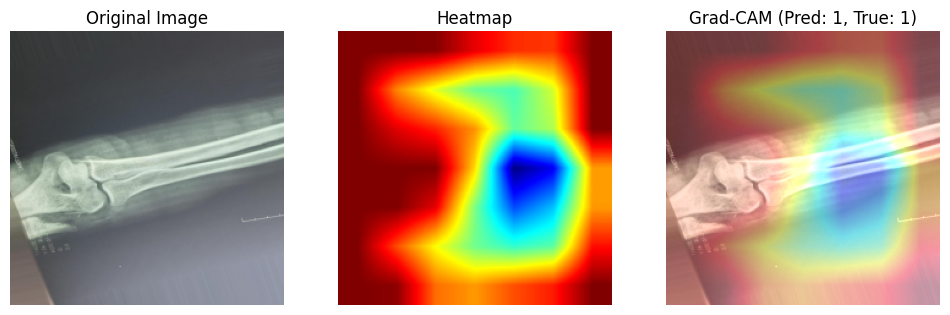

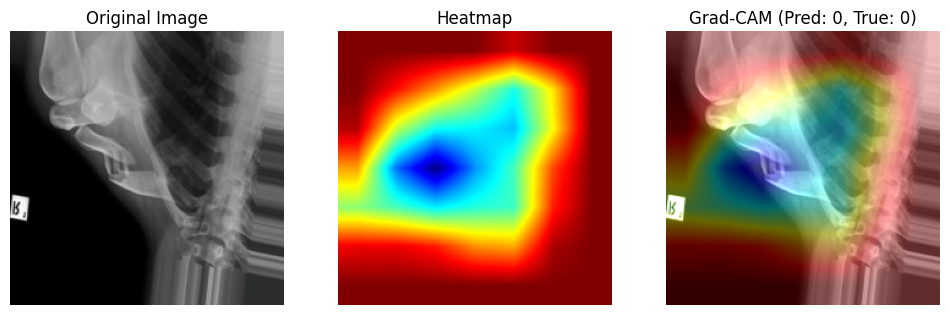

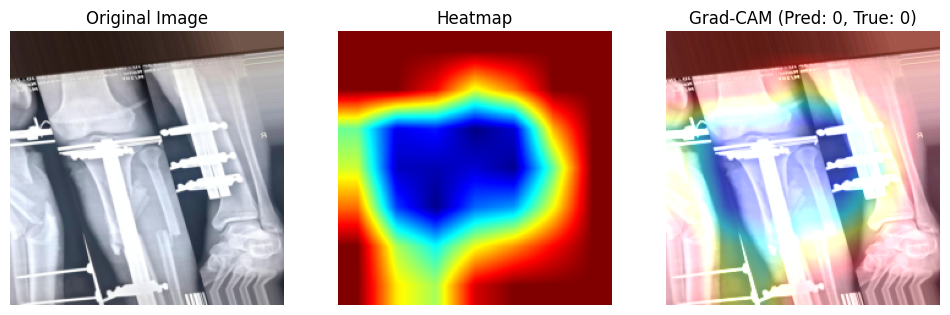

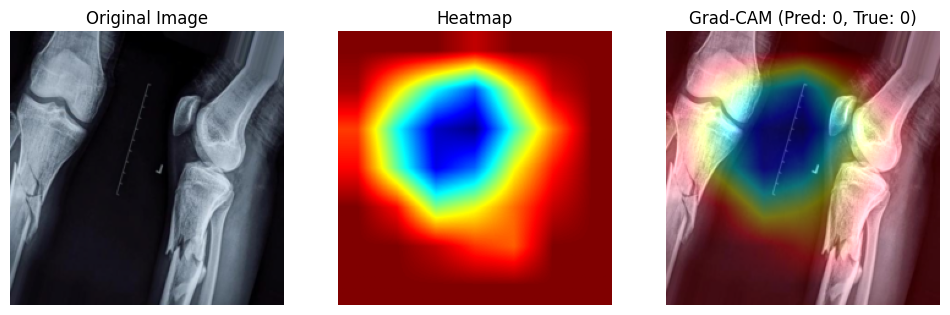

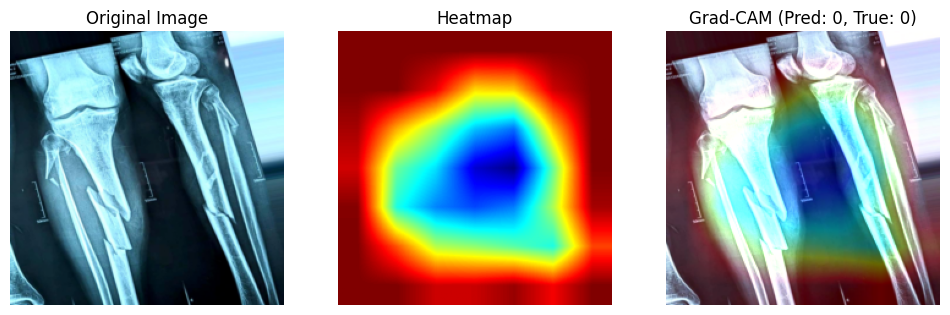

In [43]:
evaluate_and_visualize(model, test_loader, criterion, device, num_images_to_show=5)

## 🔗 Referance

- https://huggingface.co/docs/timm/feature_extraction
- https://huggingface.co/docs/timm/index
- https://huggingface.co/timm
- https://timm.fast.ai/
- https://github.com/huggingface/pytorch-image-models
- https://www.kaggle.com/code/orvile/pytorch-resnet18-binary-stroke-detection-96
- https://www.kaggle.com/code/orvile/sperm-morphology-classification-pytorch

<p style="font-size: 1.2em; margin-top: 20px;">🇹🇷 Eğer bu çalışmayı beğendiyseniz, lütfen bir <span style="font-size: 1.5em;">⬆️</span> yukarı oy vermekten çekinmeyin! 😊</p>
<p style="font-size: 1.2em;">🇬🇧 If you liked this work, please don't hesitate to give an <span style="font-size: 1.5em;">⬆️</span> upvote! 👍</p>

</body>